# Maximum Likelihood Parameter Estimation

## Review of our lecture
In the lecture we considereed the following problem


1.   We have $C$ labels with priors (unknown) probabilities $P(\omega_j), j=1, \cdots, C$.  We must have $\Sigma_{j=1}^{C} P(\omega_j) = 1$.

2.   For each label $\omega_j$ we have access to a set of instances with features ${\bf x}_{j,i}, i=1, \cdots, N_j $. We call this set $D_j = \{ {\bf x}_{j,1}, {\bf x}_{j,2}, \cdots, {\bf x}_{j,N_j} \} $

1.   We assume that these instances are generated independently, so that $
p({\bf x}_{j,m}, {\bf x}_{j,n}| \omega_j) =  p({\bf x}_{j,m}| \omega_j) \cdot  p( {\bf x}_{j,n}| \omega_j)$.

2.   The instances of one label are identically disributed, so for label $j$, all instance  have the same $ {\bf x}_{j,m}  \sim p({\bf x} | \omega_j) $. Where $p({\bf x} | \omega_j)$ is a pdf (or in discrete cases pmf) conditioned on hypothesis $\omega_j$, that is defined by the model we choose. In lecture we gave an example of a Gaussian distribution for this. In that case the we can write  ${\bf x}_{j,m} \sim N({\bf {\mu_x}}_j,\Sigma_j )=  \frac{1}{\sqrt{(2 \pi )^d \det(\Sigma_j)} }
e^{-\frac{({\bf x}-{\bf {\mu_x}}_j)^T\Sigma_j^{-1}({\bf x}-{\bf {\mu_x}}_j)}{2}} $, here ${\bf {\mu_x}}_j$ and $\Sigma_j$ are  the parameters of this Gaussian distribution. We can denote these parameters by $\Theta_j = \{{\bf {\mu_x}}_j, \Sigma_j \}$

Our task


*   Find the parameters $\Theta_j,$ for each one of our labels $j=1, \cdots, C$.

We use Maximum Likelihood Estimation (MLE) to obtain the estimates of the desired parameters:

$$
\hat{\Theta}_{j,ML} = \underset{\theta}{argmax} ~ p(D_j | \Theta = \theta)
$$
Or equivalently (as the logarithm is a monotonically increasing function),
$$
\hat{\Theta}_{j,ML} = \underset{\theta}{argmax} ~ \ln\left(p (D_j | \Theta = \theta)\right )
$$
Which is equivalent of
$$
\hat{\Theta}_{j,ML} = \underset{\theta}{argmax} ~ \ln\left( p(x_{j,1},  x_{j,2}, \cdots, x_{j,N_j}| \Theta = \theta)\right )
$$
This is potentially a very difficult optimization problem. The assumption of identically indepened distribution or i.i.d. comes to our rescue and we can write the optimization in a much more managable form. Following the independence assumption of instances, we can rewrite the joint pdf as the product of the marginal pdfs and following the identically distributed all marginals are coming from the same PFD:

$$
\hat{\Theta}_{j,ML} = \underset{\theta}{argmax} ~ \ln\left(\prod_{m=1}^{N_j} p({\bf x}_{j,m}| \Theta = \theta)\right )
$$


Here, we review two cases:

#### **Case 1: Scalar Feature (single feature)**

For this case we have
$$
\hat{\Theta}_{j,ML} = \underset{\theta}{argmax} ~ \prod_{m=1}^{N_j} p({ x}_{j,m}| \Theta = \theta)
$$
where
$$
p({ x}_{j,m}| \Theta = \theta) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x_{j,m}-\mu)^2}{2\sigma^2}}
$$
As derived in class, the parameters of the distribution are estimated as follows. The unbiased ML estimate for the mean is
$$
\hat {\mu}_{j,ML} = \frac{1}{N_j}\sum_{m=1}^{N_j}x_{j,m}
$$
and the biased ML estimate for the variance is
$$
\hat {\sigma}^2_{j,ML} = \frac{1}{N_j}\sum_{m=1}^{N_j} (x_{j,m}- \hat {\mu}_{j,ML})^2
$$
Furthermore, we saw that the unbiased estimate of the variance can be written as
$$
\hat {\sigma}^2_{j,ML} = \frac{1}{N_j-1}\sum_{m=1}^{N_j} (x_{j,m}- \hat {\mu}_{j,ML})^2
$$
#### **Case 2: Multivariate Feature (vector of features)**
For the case where each instance has a vector of features that are governed by a multivariate pdf, we have
$$
\hat{\Theta}_{j,ML} = \underset{\theta}{argmax} ~ \prod_{m=1}^{N_j} p({\bf x}_{j,m}| \Theta = \theta)
$$
where
$$
p({\bf x}_{j,m}| \Theta = \theta) = \frac{1}{\sqrt{(2 \pi )^d \det(\Sigma)} }
e^{-\frac{({\bf x}_{j,m}-{\bf {\mu_x}})^T\Sigma^{-1}({\bf x}_{j,m}-{\bf {\mu_x}})}{2}}
$$
We saw in lecture that the parameters of the distribution are estimated as follows. the nbiased ML estimate of the mean can be obtained by
$$
\hat {\bf \mu}_{j,ML} = \frac{1}{N_j}\sum_{m=1}^{N_j} {\bf x}_{j,m}
$$
and the biased ML estimate for the covariance matrix given by
$$
\hat {\Sigma}^2_{j,ML} = \frac{1}{N_j}\sum_{i=1}^{N_j} ({\bf x}_{j,m}- \hat {\bf \mu}_{j,ML}) ({\bf x}_{j,m}- \hat {\bf \mu}_{j,ML})^T
$$
Furthermore, we saw that the unbiased estimate of the covariance matrix can be written as
$$
\hat {\Sigma}^2_{j,ML} = \frac{1}{N_j-1}\sum_{m=1}^{N_j} ({\bf x}_{j,m}- \hat {\bf \mu}_{j,ML}) ({\bf x}_{j,m}- \hat {\bf \mu}_{j,ML})^T
$$


## Distinction between Baysian Classification and MLE parameter estimation

Both are called (and, indeed are) maximum likelihood (ML).
In the latter, MLE parameter estimation, we estimate the parameters (such as mean and variance) of the pdf (or pmf) for each label given the training data with the same label. Whereas, in the former Baysian classification, we assume that the the pdf (or pmf) is already given (after employing ML parameter estiamtion), and when we are proviede with a new instance, we find its proper label.

## Revisiting our Bayes decision discriminant function example

Let us remember that in the clssification problem ( for a simple two label problem which can be extended to a multi-label case) we solved the following problem


*  If $P(\omega_1)=P(\omega_2)=\frac{1}{2}$ or when we don't know the probability of the two labels, we use  a maximum likelihood Classification. In other word we have the following

$$
P({\bf x}|\omega = \omega_1) \underset{\omega_2}{\overset{\omega_1}{\gtrless}} P({\bf x}| \omega = 2)
$$
*  If $P(\omega_1)\ne P(\omega_2)$ then an optimal classifier is  a MAP Classifier. In other word we have the following

$$
P({\bf x}|\omega = \omega_1) P(\omega_1) \underset{\omega_2}{\overset{\omega_1}{\gtrless}} P({\bf x}| \omega = 2) P(\omega_2)
$$

Therefore, for MAP estimation, in the case where the features in each class are distributed according to a Gaussian distribution, we have
$$
 \frac{1}{\sqrt{(2 \pi )^d \det(\Sigma_1)} }
e^{-\frac{({\bf x}-{\bf {\bf \mu_1}})^T\Sigma_1^{-1}({\bf x}-{\bf {\bf \mu_1}})}{2}}  P(\omega_1) \underset{\omega_2}{\overset{\omega_1}{\gtrless}} \frac{1}{\sqrt{(2 \pi )^d \det(\Sigma_2)} }
e^{-\frac{({\bf x}-{\bf {\mu_2}})^T\Sigma_2^{-1}({\bf x}-{\bf {\mu_2}})}{2}} P(\omega_2)
$$

From there, we argued that testing this inequality (for the two label case) does not change if we applied a monotinically increasing function to both sides. For example, we might multiply both sides by $\sqrt{(2\pi )^d}$, and the classification would not change. Hence we could get increasingly simple discriminant functions.

Recall our example of classifying a fish between a sea bass and a salmon. In one of the cases of Bayesian classification we saw, we considered the case where:

*  The priors are equal, $P(\omega_1)= P(\omega_2)$ (so both salmon and sea bas are equally probable)
*  The features are independent (so the fish's weight and its shade of grey are independent)
*  The features have been scaled to have the same covariance matrices

Then the simplified discriminant function used to discern between the two labels was:
$$
\begin{align}
g_{i,indep,scaled,equal~priors}({\bf x})
&=\frac{-1}{2\sigma^2}\left( -2{\bf \mu_i}^T{\bf x}+{\bf \mu_i}^T{\bf \mu_i}\right)\\
&=\frac{1}{\sigma^2} {\bf \mu_i}^T{\bf x}+\frac{-1}{2\sigma^2}{\bf \mu_i}^T{\bf \mu_i}\\
\end{align}
$$ Since $\sigma^2>0$, the discriminant can be further simplified to:
\begin{align}
g_{i,indep,scaled,equal~priors,simpler}({\bf x})
&= {\bf \mu_i}^T{\bf x}+\frac{-1}{2}{\bf \mu_i}^T{\bf \mu_i}\\
\end{align}

Then the decision boundary is the line on the feature space that divides it into the two decision regions: $R_1$ where all fish whose weight and shade of grey fall will be labeled sea bass, and $R_2$ for all fish whose weigth and shade of grey fall and will be labeled salmon. This decision boundary can be found by noting that along this boundary, the two discriminants are equal:
$$
g_{1,indep,scaled,equal~priors,simpler}({\bf x})=g_{2,indep,scaled,equal~priors,simpler}({\bf x})
$$ When we plug int the formulas for each, we get:
$$
\begin{align}
{\bf \mu_1}^T{\bf x}+\frac{-1}{2}{\bf \mu_1}^T{\bf \mu_1}&={\bf \mu_2}^T{\bf x}+\frac{-1}{2}{\bf \mu_2}^T{\bf \mu_2}\\
 \frac{-1}{2}{\bf \mu_1}^T{\bf \mu_1} +\frac{1}{2}{\bf \mu_2}^T{\bf \mu_2} &=  {\bf \mu_2}^T{\bf x}-{\bf \mu_1}^T{\bf x} \\
 \Rightarrow ~~~~~~~~\left( {\bf \mu}_2 - {\bf \mu}_1 \right )^T {\bf x}   &=\frac{1}{2}  \left({\bf \mu}_2^T {\bf \mu}_2 -{\bf \mu}_1^T {\bf \mu}_1 \right)\\
\end{align}
$$

As we saw in lecture, we can rename the constants (whatever is not a feature) as ${\bf w} = \left( {\mu}_2 - {\mu}_1 \right )$ and $b =\frac{1}{2} \left ({\mu}_2^T {\mu}_2 -{\mu}_1^T {\mu}_1 \right ) $, allowing us to write a linear function of the feature vector:
 $$
 {\bf w}^T {\bf x} = b
 $$



 ## Revisiting our Bayes decision discriminant function example for a more general case

Now consider a slightly more general case(not the most general but important). This means that  the $d$ dimmesional feature vector ${\bf x}$ is conditionally distributed according to a Gaussian distribution with mean ${\bf \mu}$ and covariance matrix$\Sigma$, where

*  The priors are equal, $P(\omega_1)= P(\omega_2)$ (so both salmon and sea bas are equally probable)
*  The features are independent (so the fish's weight and its shade of grey are independent)
*  The features have *NOT* been scaled to have the same variance for each feature, though all labels have the same $\Sigma$

 $$
 \Sigma_i =
 \begin{bmatrix}
              \sigma_{1}^2  & 0 & \cdots &
              0  \\
              0 &
              \sigma_{2}^2 & \cdots &
              0  \\
              \vdots & \vdots &\ddots & 0 \\
              0 & 0 & \cdots &  \sigma_d^2
             \end{bmatrix} {\text for} ~~ i=1, \cdots, C
 $$

This more general case still means that the elements of the feature vector are independent but could have different variance. The independence of the elements of feature vector means that we have

$$
\begin{align}
P({\bf x} |ω=ω_i) & = \frac{1}{\sqrt{(2 \pi )^d \det(\Sigma_i)} }
e^{-\frac{({\bf x}-{\bf {\bf \mu_i}})^T\Sigma_1^{-1}({\bf x}-{\bf {\bf \mu_i}})}{2}} \\
& = \prod_{m=1}^d \frac{1}{\sqrt{2 \pi  \sigma_m^2 }}
e^{-\frac{(x_{m}- \mu_{im})^2} {2\sigma_m^2}}
\end{align}
$$

 Using a similar algebra we used above,  we can show that in general  the decision boundary for this slightly more general case is also linear  

$$
 {\bf w}^T {\bf x} = b
 $$

## Naive Bayes

This slightly general case is known as Naive Bayes. Although there are no specific assumption on independence of the elements of the feature vector we assume ( for simplicity, convinience, computational efficiency, and better data fitting) that the elements of the feature vector are independent. We also assume that for all labels the covariance vectors are the same. In otehr words

$$
\Sigma_i = \Sigma ~~~{\text for } ~~~ i =1, \cdots, C
$$

An important interpretation of this is that our data for all labels are generated with same variance and only the means are different.





# Some generalization of what we have learned so far

In MAP amd MLE classifications discussion previously we assumed that we have a perfect knowldge of the world and we know exactly what the PDF and prior probabilities are. This is the best one can do. However, having access to this information is almost always impossible. In Maximum Likelihood Estimation we have dropped the assumptions that we know the world. We just assume that the relation between features and labels can be described by a Gaussian distribution with unknown parameters ( we can have many other forms of  PDFs but for most problems Gaussian is a good model). So to solve our Machine Learning problem we first estimate the parameters of the Gaussian distribution given the "Training Data" then we use MAP or MLE classification to actually solve the classification problem. This is getting us to a more practical Machine Learning solution. Figure below shows the similarities and differences of the methods that we have learned so far.


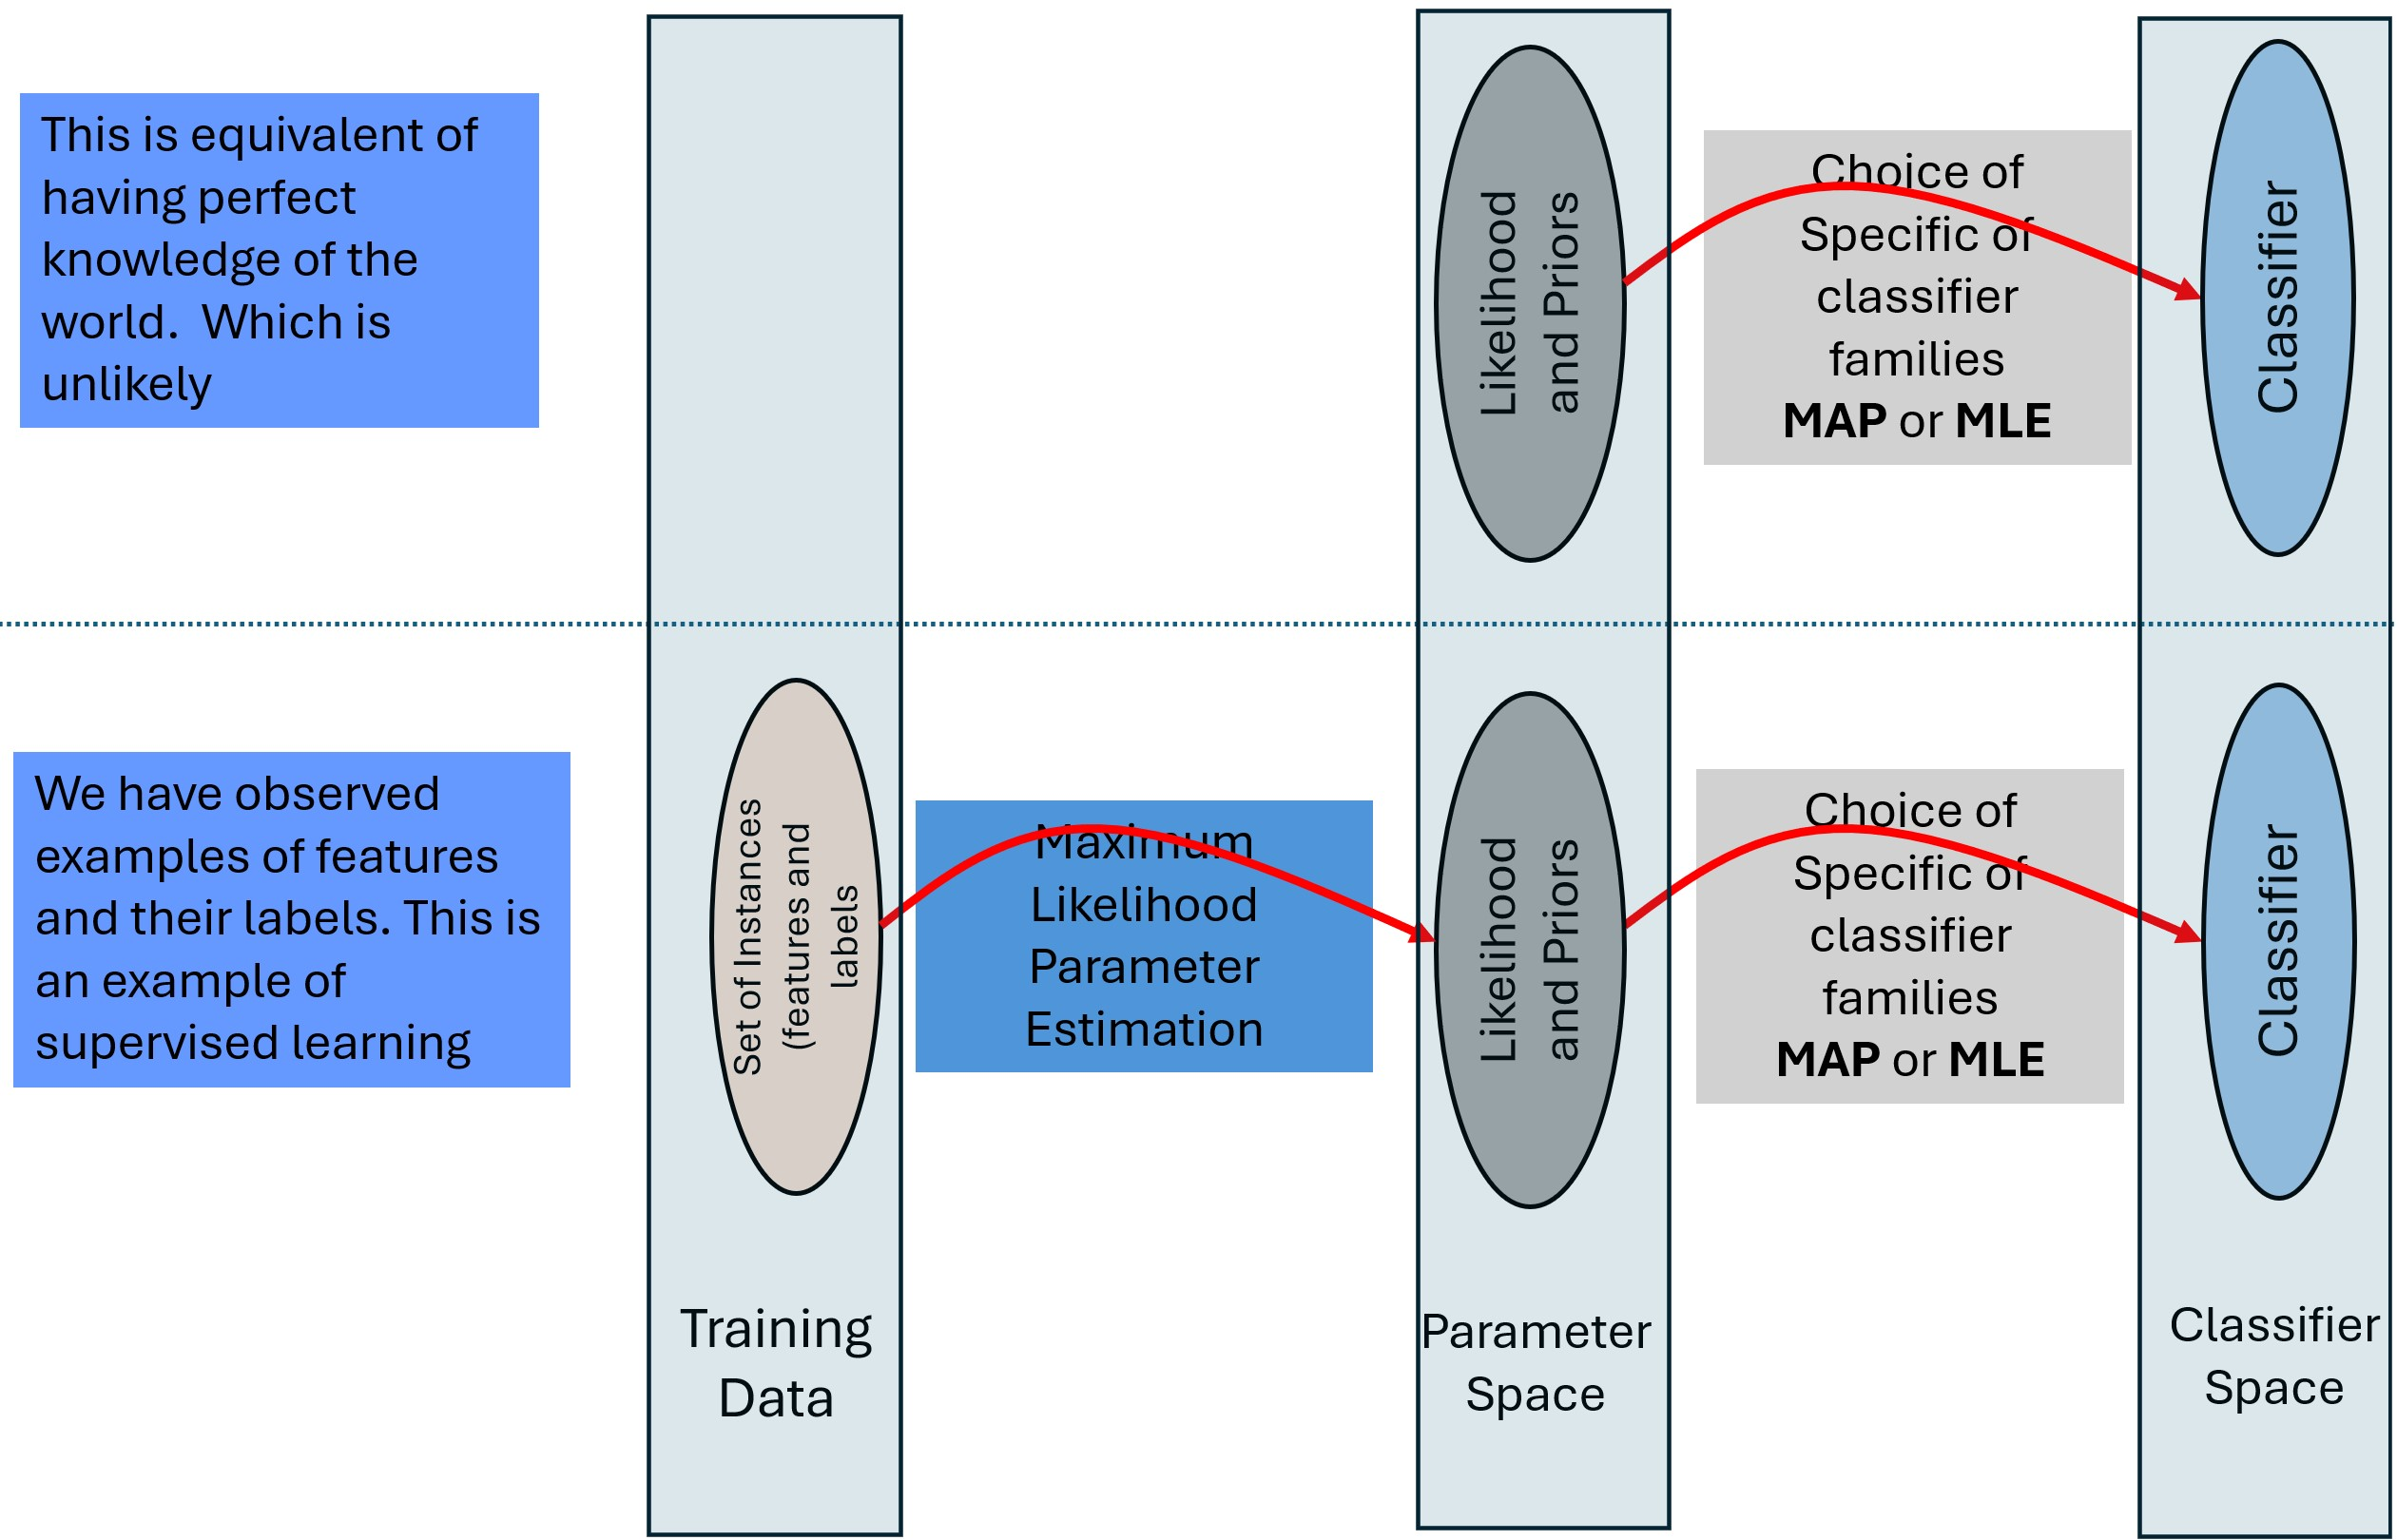

# Project 4 Instructions
In this project you are given a large set of training data points, or training instances. Some of them are created by one Guassian distributed and the rest are generated by another Gaussian distribution with different parameters.

Your task is to find the decision boundary by using this training data set.  

Consider the following:
* Each blob belongs to one label, and each label is a set of instances with a two dimensional feature vector.
* You need to estimate the mean and the covariance matrix for the instances that are given, using the material described in the class and repeated above.
* We also follow the methodology of the Naive Bayesian case (in this project $P(\omega_1) = P(\omega_2)$ )and we only estimate the diagonal elements of the covariance matrix, so we assume that the off diagonal elements are zero. This means that the features are independent from each other; this makes their estimation easier, because --- being independent --- you can estimate their means and variances independently.
* Additionally, we make sure that the two covariance matricies that are estimated for the two labels are identical, so $\Sigma_1=\Sigma_2$. Since each data set will give you a slightly different ML estimate of $\Sigma$, you can estimate them independently and then take an arithemtic average of the two estimates at the end, and then choose the average value for both labels. **NOTE:** If the two covraiance matrices are not the same for both blobs, then the boundary will not be a line, but rather a curve.
* Once you have estimated the parameters of the features for the two Gaussian distributed labels, you can use the code similar to the one we had in Project 3 to plot the decision boundary.
* Make sure that the decision boundary is linear.

## The following code will generate the data sets for you

We use the datasets feature of scikitLearn to create the instances for training. There are two labels, so two groups of data are created ("blobs")

You can read more about this here:
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=1000, n_features=2, centers=2, cluster_std= 1,random_state=1001)

The two blobs are generated here. Features $x_1$ are stored in the first column of X, and $x_2$ are in the second column of X. The labels for each row are stored in y.

## Next code visualizes the data
This code helps us get an idea of what the data looks like.

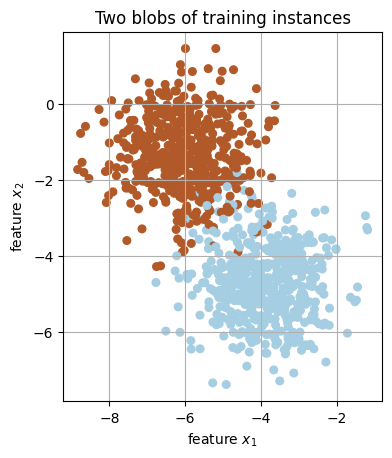

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)
plt.grid()
plt.xlabel('feature $x_1$')
plt.ylabel('feature $x_2$')
plt.title('Two blobs of training instances')
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')

**Problem 1** [3 points] You need to write a code using ML to estimate the two mean vectors, $\mu_1$ and $\mu_2$, and the covariance matrix, $\Sigma$, for these two blobs. Again remember to make sure that the covariance matrix is diagonal. Make sure that the covariance matrices for both blobs are identical (estimate one covariance matrix for each blob then average them). Use the average covarinace matrix for both blobs.

In [ ]:

# assume blob1 and blob2 are numpy arrays of shape (N, d)

# Computing mean vectors
mu1 = np.mean(blob1, axis=0)
mu2 = np.mean(blob2, axis=0)

# computing covariance matrices
cov1 = np.cov(blob1, rowvar=False)
cov2 = np.cov(blob2, rowvar=False)

# force diagonal
cov1 = np.diag(np.diag(cov1))
cov2 = np.diag(np.diag(cov2))

# average covariance
Sigma = (cov1 + cov2) / 2

print("Mean vector μ1:", mu1)
print("Mean vector μ2:", mu2)
print("Shared diagonal covariance matrix Σ:\n", Sigma)


Mean vector μ1: [-3.89791289 -4.72871334]
Mean vector μ2: [-6.02745615 -1.34040907]
Shared diagonal covariance matrix Σ:
 [[0.9071097  0.        ]
 [0.         0.97192794]]


**Problem 2** [2 points] Then, use portions of the code in Project 3 to find the boundary line between the two decision regions. Your code must graph the data superimposed on the decision regions, clearly showing the decision boundary.